# 🧠 TB Detection using Chest X-ray Images

This notebook trains a model to detect Tuberculosis from chest X-ray images using transfer learning and handles class imbalance using class weights.

In [2]:
# 📦 Install & Import Required Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# ✅ Set Paths & Parameters
DATASET_DIR = '../../../ai-microclinic-dataset/TB_Chest_Radiography_Database'  # Update path if needed
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

In [3]:
# 📂 Split Dataset using ImageDataGenerator
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=10,
    shear_range=0.1
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_data = train_gen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


In [4]:
# 📊 Compute Class Weights
labels = train_data.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 0.6, 1: 3.0}


In [5]:
# 🔧 Build the Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# 🚀 Train the Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weights
)

c:\Users\hp\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.8748 - loss: 0.3008 - val_accuracy: 0.9488 - val_loss: 0.1306
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 98s 931ms/step - accuracy: 0.9564 - loss: 0.0930 - val_accuracy: 0.9167 - val_loss: 0.1981
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9681 - loss: 0.0882 - val_accuracy: 0.9869 - val_loss: 0.0348
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9796 - loss: 0.0517 - val_accuracy: 0.9905 - val_loss: 0.0273
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9834 - loss: 0.0422 - val_accuracy: 0.9774 - val_loss: 0.0620
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9770 - loss: 0.0524 - val_accuracy: 0.9929 - val_loss: 0.0237
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9768 - loss: 0.0698 - val_accuracy: 0.9631 - val_loss: 0.0772
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 153s 911ms/step - accuracy: 0.9800 - loss: 0.0537 - val

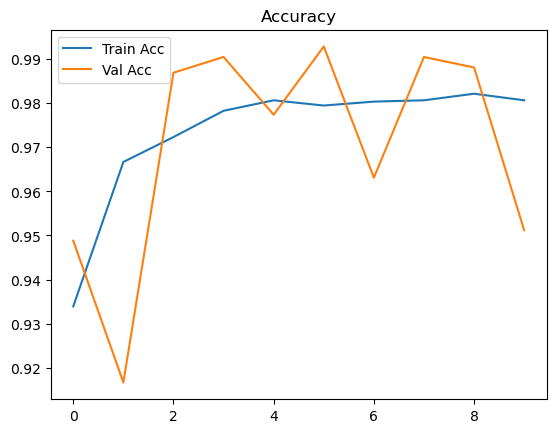

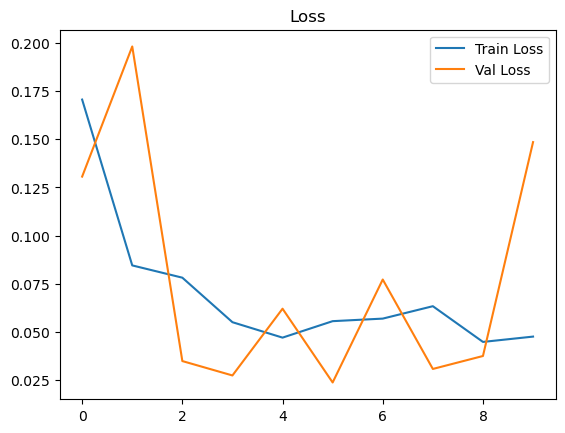

In [7]:
# 📈 Plot Training History
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 740ms/step
Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97       700
          TB       0.78      1.00      0.88       140

    accuracy                           0.95       840
   macro avg       0.89      0.97      0.92       840
weighted avg       0.96      0.95      0.95       840



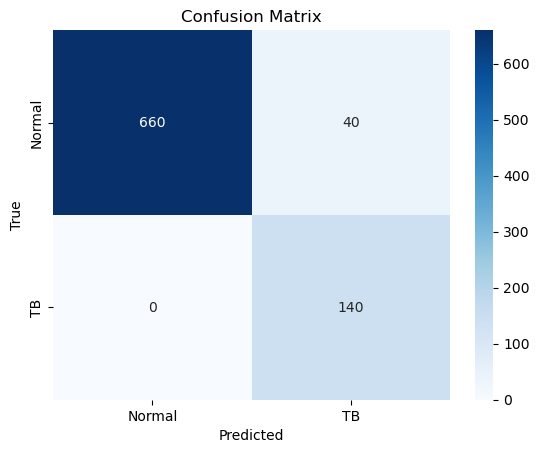

In [8]:
# 📊 Evaluation on Validation Set
val_data.reset()
preds = model.predict(val_data)
pred_labels = (preds > 0.5).astype(int)
true_labels = val_data.classes

print("Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=["Normal", "TB"]))

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "TB"], yticklabels=["Normal", "TB"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# 💾 Save Model
model.save('tb_model.h5')

In [4]:
import tensorflow

model = tensorflow.keras.models.load_model("../../../ai-microclinic-offline-dataset/Tuberclosis/tb_model.h5")

In [10]:
# 🔁 Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('tb_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite model saved as tb_model.tflite")

INFO:tensorflow:Assets written to: C:\Users\hp\AppData\Local\Temp\tmpd1f2volk\assets


INFO:tensorflow:Assets written to: C:\Users\hp\AppData\Local\Temp\tmpd1f2volk\assets


Saved artifact at 'C:\Users\hp\AppData\Local\Temp\tmpd1f2volk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2183380263248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380261520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380266320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380265936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380264784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380266512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380264976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380267088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380266704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2183380264592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  21833802

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Prediction: Normal (100.00%)


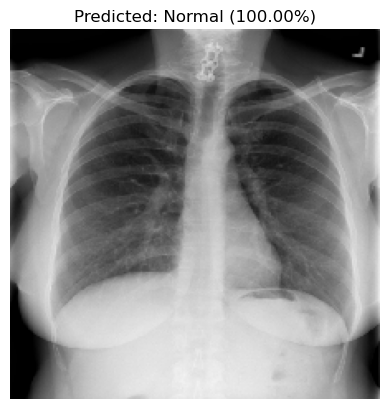

In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

IMAGE_SIZE = (224, 224)

def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)[0][0]
    label = "TB Detected" if prediction > 0.5 else "Normal"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    
    print(f"Prediction: {label} ({confidence*100:.2f}%)")
    
    # Display the image
    plt.imshow(img)
    plt.title(f"Predicted: {label} ({confidence*100:.2f}%)")
    plt.axis('off') # Hide axes ticks and labels
    plt.show()

# Assuming 'model' is already loaded and available in your environment.
# For example, if you saved your model as 'my_tb_detection_model.h5', you would load it like this:
# from tensorflow.keras.models import load_model
# model = load_model('my_tb_detection_model.h5')

# Example usage:
# Make sure the path to your image is correct.
predict_image('../../../ai-microclinic-offline-dataset/Tuberclosis/TB_Chest_Radiography_Database/Normal/Normal-1042.png', model)

In [18]:
import numpy as np
import tensorflow as tf
from PIL import Image

interpreter = tf.lite.Interpreter(model_path="../../android/app/src/main/assets/tb_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

img = Image.open("../../../ai-microclinic-offline-dataset/Tuberclosis/TB_Chest_Radiography_Database/Normal/Normal-105.png").resize((224, 224))
img_array = np.array(img) / 255.0
img_array = img_array.astype(np.float32).reshape(1, 224, 224, 3)

interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

prediction = interpreter.get_tensor(output_details[0]['index'])[0][0]
print("Prediction:", prediction)


Prediction: 0.047191426
